In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


In [11]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)

In [16]:
train_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [17]:
train_data = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', shuffle=True, random_state=42)

In [20]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names


In [23]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classes :", len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes : 20


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [27]:
print("Training feature matrix:", X_train.shape)
print("Testing feature matrix :", X_test.shape)

Training feature matrix: (11314, 56126)
Testing feature matrix : (7532, 56126)


In [31]:
mnb=MultinomialNB()

mnb.fit(
    X_train,
    y_train,
)

y_pred_mnb=mnb.predict(X_test)

In [33]:
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [34]:
X_train_binary = (X_train > 0).astype(int)
X_test_binary = (X_test > 0).astype(int)

In [36]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    X_test_binary
)

In [38]:
import pandas as pd

results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MNB", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results)

  Model  Accuracy  Precision    Recall  F1 Score
0   MNB  0.804965   0.803648  0.804965   0.78606
1   BNB  0.680961   0.767937  0.680961   0.67244


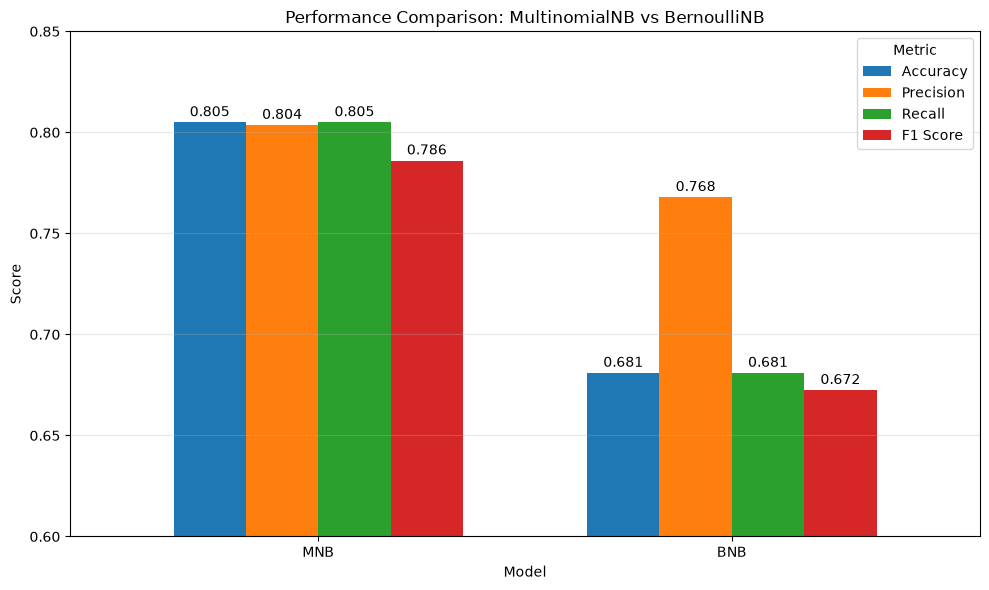

In [40]:
import matplotlib.pyplot as plt

ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6),
    width=0.7
)

plt.title("Performance Comparison: MultinomialNB vs BernoulliNB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.6, 0.85)      # <-- Changed
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()